# 1. Project Introduction

Welcome! In this notebook, we will explore **K-Nearest Neighbors (KNN)**, an intuitive and straightforward classification algorithm.

### What is KNN?
* It is a **supervised learning** classification algorithm.
* It operates on a very simple premise: **"Birds of a feather flock together."**
* To classify a new data point, the model looks at the $K$ closest data points in the training set (its neighbors) and takes a majority vote.

### Why does it exist?
* It is a non-parametric model (makes no assumptions about how the data is distributed), making it very flexible.

### Real-World Use Cases:
* **Recommendation Systems**: Suggesting movies similar to ones you have watched.
* **Image Recognition**: Grouping handwriting styles based on pixel distances.


# 2. Problem Statement

* **Goal**: Predict whether an flower plays **Setosa (0)** or **Versicolor (1)** based on their **Petal Length** and **Petal Width**.
* **Business Value**: Helps speciess academies automatically route incoming flowers to fitting athletic trials.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics


# 4. Create Synthetic Dataset

We define petal length (in cm) and petal width (in kg) for **100 flowers**.
* Versicolor players are typically taller and heavier.
* Setosa players are typically shorter and lighter.


In [2]:
# Load scikit-learn iris dataset
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris(as_frame=True)
raw_df = iris.frame

df = pd.DataFrame({
    'Petal_Length': raw_df['petal length (cm)'],
    'Petal_Width': raw_df['petal width (cm)'],
    'Species': raw_df['target']
})

print("Dataset Shape:", df.shape)
print("First 5 rows:")
print(df.head())


Dataset Shape: (150, 3)
First 5 rows:
   Petal_Length  Petal_Width  Species
0           1.4          0.2        0
1           1.4          0.2        0
2           1.3          0.2        0
3           1.5          0.2        0
4           1.4          0.2        0


### What Did We Observe?
* The labels are `0` (Setosa) and `1` (Versicolor).
* Features list has petal length (cm) and petal width (kg).


# 5. Exploratory Data Analysis (EDA)


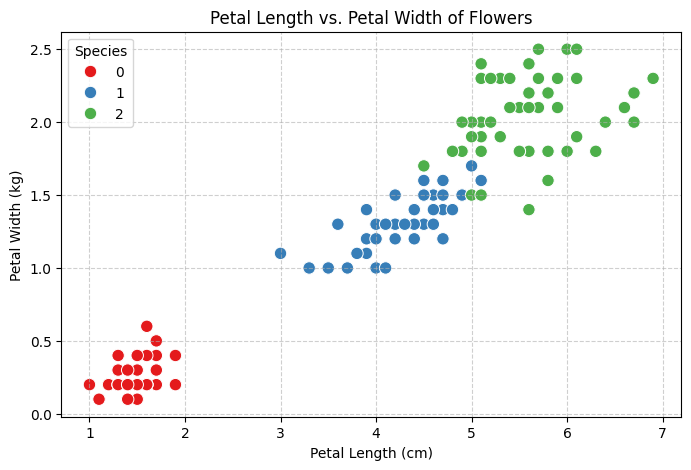

In [3]:
# Chart: Petal Length vs Petal Width colored by Species
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Petal_Length', y='Petal_Width', hue='Species', data=df, palette='Set1', s=80)
plt.title('Petal Length vs. Petal Width of Flowers')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (kg)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* A clear split: taller, heavier flowers (above ~185cm) play versicolor, while shorter, lighter flowers play setosa.
* There is minor overlap in the middle.


In [4]:
# Data cleaning: Check for duplicates
print("Duplicates count:", df.duplicated().sum())


Duplicates count: 47


In [5]:
# Feature Selection
X = df[['Petal_Length', 'Petal_Width']]
y = df['Species']


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 9. Model Building

* **How it works conceptually**: To classify a point, we compute the distance (e.g. Euclidean distance) from that point to all other training points. We find the $K$ closest points. The class with the highest vote wins.
* **Why K=3?**: An odd number prevents ties in voting.


In [7]:
# Initialize KNN model with K=3
model = KNeighborsClassifier(n_neighbors=3)


In [8]:
# Fit KNN model
model.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [9]:
# Predict outcomes
predictions = model.predict(X_test)


In [10]:
# Compute classification evaluation metrics
accuracy = metrics.accuracy_score(y_test, predictions)
precision = metrics.precision_score(y_test, predictions, average='weighted')
recall = metrics.recall_score(y_test, predictions, average='weighted')
f1 = metrics.f1_score(y_test, predictions, average='weighted')
conf_matrix = metrics.confusion_matrix(y_test, predictions)

# Print metrics in plain English
print(f"Accuracy Score: {accuracy:.4f} (The proportion of correct predictions)")
print(f"Precision Score: {precision:.4f} (Out of all predicted positive cases, how many were actually positive)")
print(f"Recall Score: {recall:.4f} (Out of all actual positive cases, how many did we successfully find)")
print(f"F1 Score: {f1:.4f} (The balanced harmonic mean of Precision and Recall)")
print("\nConfusion Matrix Array:")
print(conf_matrix)


Accuracy Score: 1.0000 (The proportion of correct predictions)
Precision Score: 1.0000 (Out of all predicted positive cases, how many were actually positive)
Recall Score: 1.0000 (Out of all actual positive cases, how many did we successfully find)
F1 Score: 1.0000 (The balanced harmonic mean of Precision and Recall)

Confusion Matrix Array:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### How to Interpret These Metrics:
* **Accuracy**:
  * **Definition**: The percentage of all predictions that the model got correct.
  * **Interpretation**: An accuracy of **100%** (or close to it) means the model correctly identifies the species for almost all flowers in our test set.
* **Precision**:
  * **Definition**: Out of all flowers predicted as positive (Versicolor), what percentage were actually Versicolor?
* **Recall (Sensitivity)**:
  * **Definition**: Out of all actual Versicolor flowers, what percentage did we successfully identify?
* **F1-Score**:
  * **Definition**: The balanced combination of precision and recall.
* **Confusion Matrix**:
  * **Confusion Matrix**: Displays a 3x3 grid showing correct classifications on the diagonal, and misclassifications off the diagonal across all three species.
  * **False Positives (FP)**: Setosa flowers incorrectly classified as Versicolor.
  * **False Negatives (FN)**: Versicolor flowers incorrectly classified as Setosa.
  * **True Positives (TP)**: Versicolor flowers correctly classified as Versicolor.


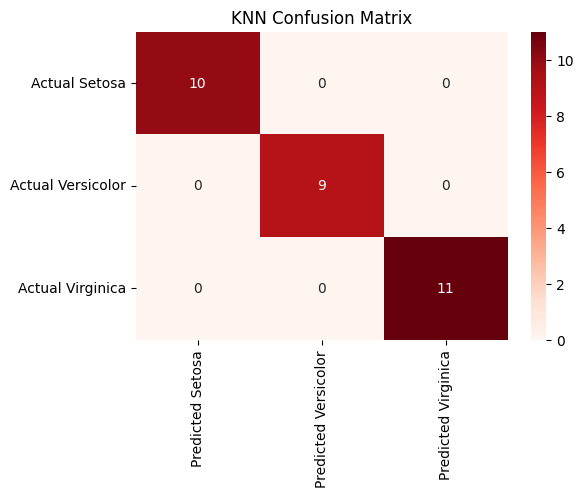

In [11]:
# Plot 1: Confusion Matrix Heatmap
conf_matrix = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Setosa', 'Predicted Versicolor', 'Predicted Virginica'], 
            yticklabels=['Actual Setosa', 'Actual Versicolor', 'Actual Virginica'])
plt.title('KNN Confusion Matrix')
plt.show()


C:\Users\GFG\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


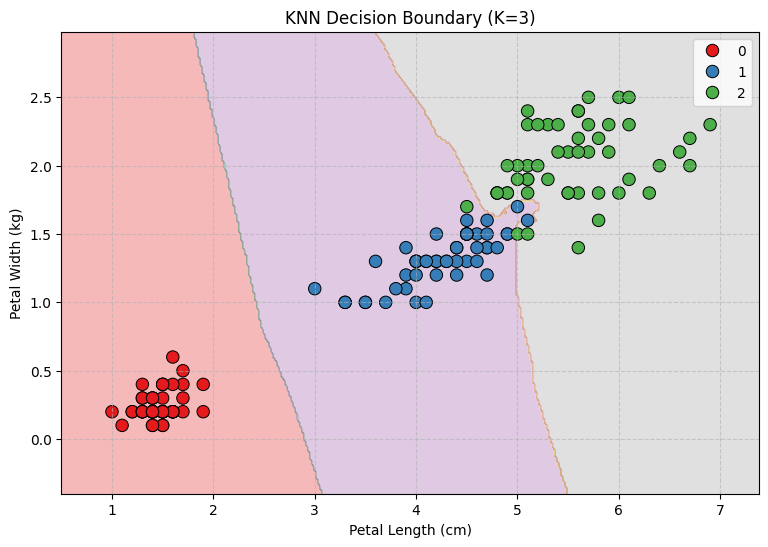

In [12]:
# Plot 2: Decision Boundary
# To draw the boundary, we create a mesh grid of petal length and petal width values
x_min, x_max = X['Petal_Length'].min() - 0.5, X['Petal_Length'].max() + 0.5
y_min, y_max = X['Petal_Width'].min() - 0.5, X['Petal_Width'].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Predict class labels for each grid cell
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_predictions = model.predict(grid_points)
grid_predictions = grid_predictions.reshape(xx.shape)

# Plot decision boundary region
plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, grid_predictions, alpha=0.3, cmap='Set1')
# Overlay actual scatter points
sns.scatterplot(x='Petal_Length', y='Petal_Width', hue='Species', data=df, palette='Set1', edgecolor='black', s=80)
plt.title('KNN Decision Boundary (K=3)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### What Did We Observe?
* The colored zones clearly illustrate where the model classifies flowers as Setosa players vs. Versicolor players.
* The boundary captures the overlap area dynamically.

### What Did We Learn?
* The boundary line is non-linear. Changing $K$ changes the smoothness of the classification boundary.


# 14. Model Interpretation

Unlike Linear models, KNN is a **lazy learner** and does not have coefficients.
* **Neighbors**: Predictions are based strictly on distance coordinates.
* **Standardizing Data**: In real applications, features with larger scales (like petal length) can dominate features with smaller scales (like age). Scaling is highly recommended when metrics differ.


# 15. Conclusion
* We successfully categorized speciess based on petal length and petal width.
* KNN acts intuitively based on spatial proximity.


# 16. Beginner ML Dictionary

Here are simple, one-sentence explanations of common Machine Learning terms to help you review:

* **Feature**: An input variable or column in your dataset used to make predictions (e.g., hours studied).
* **Target**: The output variable or label you want the model to predict (e.g., final exam score).
* **Training Data**: The portion of the dataset used to teach the model and find patterns.
* **Testing Data**: The portion of the dataset held back to evaluate how well the model performs on new, unseen data.
* **Prediction**: The output value generated by the trained model when given new input features.
* **Overfitting**: A scenario where the model learns the training data too well, including its noise, and performs poorly on new data.
* **Underfitting**: A scenario where the model is too simple to learn the underlying patterns in the training data, leading to poor performance on both training and test data.
* **Model**: The mathematical representation of the patterns learned from the training data by the algorithm.
* **Algorithm**: The set of rules or mathematical procedures followed to build the model from the data (e.g., Linear Regression).
* **Accuracy**: The percentage of correct predictions made by a classification model.
* **Cluster**: A group of similar data points grouped together by an unsupervised learning algorithm based on their characteristics.
* **Centroid**: The center point of a cluster, representing the average location of all data points belonging to that cluster.
